# Week 2

As explained in Lecture 1, each week of this class is a Jupyter notebook like this one. In order to follow the class, you simply start reading from the top, following the instructions.

## Today

This lecture covers:

1. **Principles of good visualization**: We'll watch a video on what makes plots effective and create your own checklist.
2. **Merging messy real-world datasets**: You'll combine SF crime data from two different time periods (2003-2018 and 2018-present) that use different schemas and categories. This is one of the most common and frustrating tasks in data science.
3. **Temporal pattern analysis**: Using your merged 20+ year dataset, you'll explore crime patterns across years, months, weekdays, and hours.
4. **Advanced visualization techniques**: You'll experiment with calendar plots, polar charts, and time series visualizations.

By the end, you'll have a unified crime dataset spanning two decades and the skills to wrangle similarly messy data in your future work.

## Part 1: Creating nice plots

Ok. There's a lot of barcharts today. We need them ... they are a fantastic tool for data exploration. But it can get monotonous, so let's take a little break to talk about something else before digging deeper with the barcharts.

I want to tell you a bit about how to make nice plots. I do that in the video below

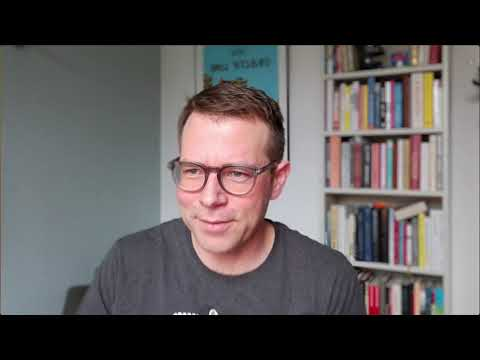

In [1]:
from IPython.display import YouTubeVideo
YouTubeVideo('9hIu4pgJXQc', width=800, height=450)

> **Exercise 1.1**: Nice plots
>
> * Create a list of 10 rules for nice plots based on the video.

<div class="alert alert-block alert-info">
<b>LLM guidance:</b> Answer in your own words, do your own research, don't use your LLM. Once you've written down your answers, it's OK to use the LLM to refine your writing.
</div>

Answers for Exercises 1.1

1. have subplots with enough space between them and they have to be readable
2. label everything
3. use meaningful values and zoom levels on the axes
4. zoom levels should be appropriate on axeses and subplots
5. data-ink ratio should be high
6. remove background, borders, redundant labels, special effects, bolding
7. fonts should be readable
8. Captions should be clear and concise

# Part 2: Merging Historical and Recent Crime Data

So far we've been working with crime data from 2018 onwards (I will assume you have that file, named something like "Police Department Incident Reports 2018 to Present"). But San Francisco has published crime data going all the way back to 2003! Having access to this longer time series would let us:
- Study long-term trends in crime
- See how crime patterns changed before, during, and after major events
- Have more statistical power for our analyses

The catch? **The two datasets don't have the same structure.** This is an incredibly common situation in data science. Organizations change how they record data over time, different departments use different formats, and merging datasets requires careful thought.

### Why This Matters

In the real world, you'll almost never get a single, clean dataset that answers your question. Instead, you'll need to combine data from multiple sources: different time periods, different departments, different organizations. Each source will have its own quirks, naming conventions, and missing values.

This is also directly relevant to algorithmic accountability. Remember the Richardson et al. reading from Week 1? They argued that "dirty data" undermines predictive policing. But what counts as "dirty"? If crime categories change over time—if `DRUNKENNESS` disappears as a category in 2018—does that mean public intoxication stopped? Or just that we can't track it anymore? These are the kinds of questions you need to ask whenever you merge datasets.

The skills you'll practice here—schema mapping, category matching, validation—are foundational for any serious data work.

### Step 2.1: Understand both schemas

> **Mini Exercise**: Schema exploration
>
> Download the historical dataset "Police Department Incident Reports: Historical 2003 to May 2018" from SF OpenData (or use the file provided).
>
> * Load both datasets and examine their columns
> * Which columns appear in both datasets (perhaps with different names)?
> * Which columns are unique to each dataset?
> * Create a "mapping" showing which columns in the historical data correspond to which columns in the recent data

Here's a starter to help you think about the mapping:

| Information | Historical Column | Recent Column |
|-------------|------------------|---------------|
| Crime type | `Category` | `Incident Category` |
| Police district | `PdDistrict` | `Police District` |
| Date | `Date` | `Incident Date` |
| ... | ... | ... |

<div class="alert alert-block alert-info">
<b>LLM guidance:</b> You should be able to do this no problem in pandas, but if you find it tough, feel free to ask an LLM for help.
</div>



In [2]:
# Step 2.1 Solution: Schema Exploration
import pandas as pd
import numpy as np

# Load the datasets with correct file paths
historical_df = pd.read_csv('../files/Police_Department_Incident_Reports__Historical_2003_to_May_2018_20260209.csv')
recent_df = pd.read_csv('../files/Police_Department_Incident_Reports__2018_to_Present_20260203.csv')

print("Historical dataset shape:", historical_df.shape)
print("Recent dataset shape:", recent_df.shape)

# Examine columns
print("\nHISTORICAL COLUMNS:")
print(historical_df.columns.tolist())
print(f"Total: {len(historical_df.columns)}")

print("\nRECENT COLUMNS:")
print(recent_df.columns.tolist())
print(f"Total: {len(recent_df.columns)}")

# Create the mapping table
mapping_data = [
    ("Crime type", "Category", "Incident Category", "HIGH"),
    ("Crime description", "Descript", "Incident Description", "HIGH"),
    ("Date", "Date", "Incident Date", "HIGH"),
    ("Time", "Time", "Incident Time", "HIGH"),
    ("Police district", "PdDistrict", "Police District", "HIGH"),
    ("Resolution", "Resolution", "Resolution", "HIGH"),
    ("Location", "Location", "Location", "HIGH"),
    ("Address", "Address", "Incident Address", "HIGH"),
    ("Latitude", "Y", "Latitude", "HIGH"),
    ("Longitude", "X", "Longitude", "HIGH"),
    ("Neighborhood", "Analysis Neighborhood", "Analysis Neighborhood", "HIGH"),
]

print("\n" + "="*60)
print("COLUMN MAPPING TABLE")
print("="*60)
print(f"{'Information':<20} | {'Historical':<25} | {'Recent':<25} | {'Confidence'}")
print("-" * 80)
for info, hist, rec, conf in mapping_data:
    print(f"{info:<20} | {hist:<25} | {rec:<25} | {conf}")

# Check data types and formats
print("\n" + "="*60)
print("DATA TYPE ANALYSIS")
print("="*60)

key_columns = {
    'Historical': ['Date', 'Time', 'Category', 'Y', 'X', 'PdDistrict'],
    'Recent': ['Incident Date', 'Incident Time', 'Incident Category', 'Latitude', 'Longitude', 'Police District']
}

for dataset_name, cols in key_columns.items():
    print(f"\n{dataset_name.upper()} DATASET:")
    df = historical_df if dataset_name == 'Historical' else recent_df
    
    for col_name in cols:
        if col_name in df.columns:
            print(f"  {col_name}: {df[col_name].dtype}")
            sample_values = df[col_name].dropna().head(3).tolist()
            print(f"    Sample: {sample_values}")
        else:
            print(f"  {col_name}: COLUMN NOT FOUND")



Historical dataset shape: (2071736, 15)
Recent dataset shape: (1003940, 29)

HISTORICAL COLUMNS:
['PdId', 'IncidntNum', 'Incident Code', 'Category', 'Descript', 'DayOfWeek', 'Date', 'Time', 'PdDistrict', 'Resolution', 'Address', 'X', 'Y', 'location', 'data_loaded_at']
Total: 15

RECENT COLUMNS:
['Row ID', 'Incident Datetime', 'Incident Date', 'Incident Time', 'Incident Year', 'Incident Day of Week', 'Report Datetime', 'Incident ID', 'Incident Number', 'CAD Number', 'Report Type Code', 'Report Type Description', 'Filed Online', 'Incident Code', 'Incident Category', 'Incident Subcategory', 'Incident Description', 'Resolution', 'Intersection', 'CNN', 'Police District', 'Analysis Neighborhood', 'Supervisor District', 'Supervisor District 2012', 'Latitude', 'Longitude', 'Point', 'data_as_of', 'data_loaded_at']
Total: 29

COLUMN MAPPING TABLE
Information          | Historical                | Recent                    | Confidence
-------------------------------------------------------------

## Step 2.2: Identify the common ground

> **Mini Exercise**: Essential columns
>
> * For the analyses we've have been doing (crime categories, time patterns, police districts), and *will be doing in future lectures* (**mapping GPS points**) which columns do we need?
> * Make a list of the essential/potentially interesting columns and their names in each dataset
> * Check the data types — are dates stored the same way? Are coordinates in the same format?
> * Handle any format differences (hint: look carefully at how dates are formatted in each file)

In [3]:
# Step 2.2 Solution: Essential Columns Analysis

print("=== ESSENTIAL COLUMNS ===")

# Essential columns for our analysis
essential = [
    ("Crime Category", "Category", "Incident Category"),
    ("Date", "Date", "Incident Date"),
    ("Time", "Time", "Incident Time"),
    ("Police District", "PdDistrict", "Police District"),
    ("Latitude", "Y", "Latitude"),
    ("Longitude", "X", "Longitude"),
    ("Description", "Descript", "Incident Description"),
    ("Resolution", "Resolution", "Resolution")
]

print("Analysis Need | Historical | Recent")
print("-" * 40)
for need, hist, rec in essential:
    print(f"{need:<15} | {hist:<10} | {rec}")

print("\n=== DATA FORMAT CHECK ===")

# Check date formats
print("Date formats:")
print(f"Historical: {historical_df['Date'].iloc[0]}")
print(f"Recent: {recent_df['Incident Date'].iloc[0]}")

# Check coordinate ranges
print("\nCoordinate ranges:")
print(f"Historical Y: {historical_df['Y'].min():.2f} to {historical_df['Y'].max():.2f}")
print(f"Historical X: {historical_df['X'].min():.2f} to {historical_df['X'].max():.2f}")
print(f"Recent Latitude: {recent_df['Latitude'].min():.2f} to {recent_df['Latitude'].max():.2f}")
print(f"Recent Longitude: {recent_df['Longitude'].min():.2f} to {recent_df['Longitude'].max():.2f}")

# Check category examples
print("\nCategory samples:")
print(f"Historical: {list(historical_df['Category'].unique()[:5])}")
print(f"Recent: {list(recent_df['Incident Category'].unique()[:5])}")

print("\n=== STANDARDIZATION NEEDED ===")
print("1. Dates: Convert to datetime")
print("2. Coordinates: Map Y→Latitude, X→Longitude")
print("3. Categories: Standardize case")
print("4. Column names: Create unified names")

=== ESSENTIAL COLUMNS ===
Analysis Need | Historical | Recent
----------------------------------------
Crime Category  | Category   | Incident Category
Date            | Date       | Incident Date
Time            | Time       | Incident Time
Police District | PdDistrict | Police District
Latitude        | Y          | Latitude
Longitude       | X          | Longitude
Description     | Descript   | Incident Description
Resolution      | Resolution | Resolution

=== DATA FORMAT CHECK ===
Date formats:
Historical: 03/03/2016
Recent: 2025/08/26

Coordinate ranges:
Historical Y: 37.71 to 90.00
Historical X: -122.51 to -120.50
Recent Latitude: 37.71 to 37.83
Recent Longitude: -122.51 to -122.37

Category samples:
Historical: ['VEHICLE THEFT', 'ASSAULT', 'TRESPASS', 'OTHER OFFENSES', 'NON-CRIMINAL']
Recent: ['Recovered Vehicle', 'Assault', 'Fraud', 'Larceny Theft', 'Lost Property']

=== STANDARDIZATION NEEDED ===
1. Dates: Convert to datetime
2. Coordinates: Map Y→Latitude, X→Longitude
3. Cat

### Step 2.3: The Category Problem

This is where things get tricky (but interesting). The crime categories in the two datasets are **not the same**.

> **Mini Exercise**: Explore the category differences
>
> * List all unique categories in each dataset
> * How many categories are in the historical data? How many in the recent data?
> * Which categories appear to match (even if the names are slightly different)?
> * Which categories exist in one dataset but not the other?

In [4]:
# Step 2.3 Solution: Category Exploration


print("=== CATEGORY ANALYSIS ===")

# Get unique categories from both datasets
hist_categories = sorted(historical_df['Category'].dropna().unique())
recent_categories = sorted(recent_df['Incident Category'].dropna().unique())

print(f"Historical categories: {len(hist_categories)}")
print(f"Recent categories: {len(recent_categories)}")

print("\nHISTORICAL CATEGORIES:")
for i, cat in enumerate(hist_categories, 1):
    print(f"{i:2d}. {cat}")

print("\nRECENT CATEGORIES:")
for i, cat in enumerate(recent_categories, 1):
    print(f"{i:2d}. {cat}")

# Find potential matches by comparing lowercase
print("\n=== POTENTIAL MATCHES ===")
matches = []
for hist_cat in hist_categories:
    hist_lower = hist_cat.lower().replace(' ', '').replace('-', '').replace('/', '')
    for recent_cat in recent_categories:
        recent_lower = recent_cat.lower().replace(' ', '').replace('-', '').replace('/', '')
        if hist_lower == recent_lower:
            matches.append((hist_cat, recent_cat))
            break

print("Historical -> Recent:")
for hist, recent in matches:
    print(f"  {hist} -> {recent}")

# Categories unique to each dataset
hist_only = [cat for cat in hist_categories if cat.lower() not in [c.lower() for c in recent_categories]]
recent_only = [cat for cat in recent_categories if cat.lower() not in [c.lower() for c in hist_categories]]

print(f"\nCATEGORIES ONLY IN HISTORICAL ({len(hist_only)}):")
for cat in hist_only:
    print(f"  - {cat}")

print(f"\nCATEGORIES ONLY IN RECENT ({len(recent_only)}):")
for cat in recent_only:
    print(f"  - {cat}")

print(f"\n=== SUMMARY ===")
print(f"Total unique categories: {len(hist_categories) + len(recent_categories)}")
print(f"Direct matches: {len(matches)}")
print(f"Historical-only: {len(hist_only)}")
print(f"Recent-only: {len(recent_only)}")

=== CATEGORY ANALYSIS ===
Historical categories: 37
Recent categories: 49

HISTORICAL CATEGORIES:
 1. ARSON
 2. ASSAULT
 3. BAD CHECKS
 4. BRIBERY
 5. BURGLARY
 6. DISORDERLY CONDUCT
 7. DRIVING UNDER THE INFLUENCE
 8. DRUG/NARCOTIC
 9. DRUNKENNESS
10. EMBEZZLEMENT
11. EXTORTION
12. FORGERY/COUNTERFEITING
13. FRAUD
14. GAMBLING
15. KIDNAPPING
16. LARCENY/THEFT
17. LIQUOR LAWS
18. LOITERING
19. MISSING PERSON
20. NON-CRIMINAL
21. OTHER OFFENSES
22. PORNOGRAPHY/OBSCENE MAT
23. PROSTITUTION
24. RECOVERED VEHICLE
25. ROBBERY
26. SECONDARY CODES
27. SEX OFFENSES, FORCIBLE
28. SEX OFFENSES, NON FORCIBLE
29. STOLEN PROPERTY
30. SUICIDE
31. SUSPICIOUS OCC
32. TREA
33. TRESPASS
34. VANDALISM
35. VEHICLE THEFT
36. WARRANTS
37. WEAPON LAWS

RECENT CATEGORIES:
 1. Arson
 2. Assault
 3. Burglary
 4. Case Closure
 5. Civil Sidewalks
 6. Courtesy Report
 7. Disorderly Conduct
 8. Drug Offense
 9. Drug Violation
10. Embezzlement
11. Fire Report
12. Forgery And Counterfeiting
13. Fraud
14. Gambling
15.

### Intermezzo: The many flavors of category mismatch

Here are some concrete problems you'll discover:

**Problem 1: Case and formatting differences**

The historical data uses ALL CAPS (`ASSAULT`, `BURGLARY`) while the recent data uses Title Case (`Assault`, `Burglary`). This is easy to fix with `.str.upper()` or `.str.lower()`.

**Problem 2: Name changes**

Some categories look like they were simply renamed:
- `VEHICLE THEFT` → `Motor Vehicle Theft`

**Problem 3: Categories that split or merged**

This is trickier. For example:
- The historical `SEX OFFENSES` might correspond to multiple recent categories: `Sex Offense`, `Rape`, `Human Trafficking`
- The recent data has both `Drug Offense` and `Drug Violation` — should these both map to the historical `DRUG/NARCOTIC`?
- `VANDALISM` in historical data — is that `Vandalism` or `Malicious Mischief` in the recent data? Or both?

**Problem 4: Categories that disappeared or appeared**
- `DRUNKENNESS` exists in historical data but not in recent — was it merged into something else? Decriminalized? Maybe Google it or ask an LLM.
- `Traffic Collision` exists in recent data but not historical — is this a new category, or was it previously recorded differently?
- `Human Trafficking` appears in recent data — is this genuinely new, or was it previously categorized under something else?

**Problem 5: Ambiguous mappings**

Sometimes it's genuinely unclear how categories should map. Does historical `WEAPON LAWS` correspond to recent `Weapons Offense`, `Weapons Carrying Etc`, or both? Without detailed documentation (which often doesn't exist), you have to make judgment calls.

### Step 2.4: Solving the category problem

There are two ways that I can think of to approach this matching problem:

**Approach A: Manual inspection**

Look at both lists carefully and create mappings based on your judgment. 

**Approach B: Use an LLM to help**

LLMs have broad background knowledge about crime categories, legal terminology, and how classification systems work. I think that they might be surprisingly helpful here.

> **Exercise 2.1**: LLM-assisted category matching
>
> Try asking an LLM to help you match categories. Here's a suggested approach:
>
> 1. Give the LLM both lists of categories
> 2. Ask it to suggest which categories likely correspond to each other
> 3. Ask it to explain *why* it thinks certain categories match (this helps you evaluate its suggestions)
> 4. Ask it to flag any ambiguous cases where human judgment is needed
>
> **Important**: Don't blindly trust the LLM's suggestions! Use them as a starting point, then verify as described below.

<div class="alert alert-block alert-info">
<b>LLM guidance:</b> This is a <i>great</i> use case for LLMs — they have background knowledge about how crime categories work and can spot likely matches faster than manual inspection. But remember: the LLM is making educated guesses based on names. Always verify its suggestions against actual data when possible (see below).
</div>

#### The crucial last step: Data-driven validation

Even after creating a mapping, you should validate it:
- For categories you've matched, do the counts make sense? If `VANDALISM` mapped to `Malicious Mischief`, do you see roughly similar numbers of incidents per year?
- Look at the transition year (2018) — if your mapping is correct, the yearly/monthly trend should make sense. A sudden jump or drop suggests a mapping problem.

### Step 2.5: Define your Personal Focus Crimes

Given all these complications, it's time to make some decisions. You need to define a set of **Personal Focus Crimes** — categories that you can confidently track across both datasets.

> **Exercise 2.2**: Define Personal Focus Crimes
>
> Create a list of crime categories that:
> 1. Exist in both datasets (possibly with different names)
> 2. Have a mapping between the two naming systems that you trust based on checking trendlines
> 3. Are interesting enough to analyze (not too rare, not just "Other")
>
> For each Personal Focus Crime, document:
> - The name you'll use in your merged dataset
> - The corresponding category name in the historical data
> - The corresponding category name(s) in the recent data
> - Your confidence level (high/medium/low) in the mapping
> - Any notes or caveats
>
> **Example format:**
>
> | Personal Focus Crime | Historical | Recent | Confidence | Notes |
> |---------------------|------------|--------|------------|-------|
> | Assault | ASSAULT | Assault | High | Direct match |
> | Burglary | BURGLARY | Burglary | High | Direct match |
> | Drug Offense | DRUG/NARCOTIC | Drug Offense, Drug Violation | Medium | Merged two recent categories |
> | Vehicle Theft | VEHICLE THEFT | Motor Vehicle Theft | High | Name change only |
> | ... | ... | ... | ... | ... |
>
> It's completely fine if your Personal Focus Crimes list is shorter than our original focus crimes list. **Quality over quantity** — it's better to have 8 crimes you can track confidently than 16 where half are questionable.

<div class="alert alert-block alert-info">
<b>LLM guidance:</b> Use your LLM to help identify good candidates and spot potential issues, but <b>you</b> need to make the final decisions about what goes on your list. These are judgment calls that affect all your downstream analysis.
</div>

| Personal Focus Crime | Historical | Recent | Confidence | Notes |
|---------------------|------------|--------|------------|-------|
| Assault | ASSAULT | Assault | High | Direct match, straightforward tracking |
| Burglary | BURGLARY | Burglary | High | Exact match, easy to trace |
| Larceny / Theft | LARCENY/THEFT | Larceny Theft | High | Direct mapping; no ambiguity |
| Robbery | ROBBERY | Robbery | High | Clear match |
| Arson | ARSON | Arson | High | Direct match |
| Drug Offense | DRUG/NARCOTIC | Drug Offense, Drug Violation | Medium | Combined two recent categories; slight uncertainty due to minor vs major offenses |
| Vehicle Theft | VEHICLE THEFT | Motor Vehicle Theft | High | Name change only |
| Embezzlement | EMBEZZLEMENT | Embezzlement | High | Direct match |
| Fraud | FRAUD | Fraud | High | Direct match |
| Vandalism | VANDALISM | Vandalism, Malicious Mischief | Medium | Some variation in naming; mostly property damage |
| Liquor Laws | LIQUOR LAWS | Liquor Laws | High | Direct match |
| Suicide | SUICIDE | Suicide | High | Clear match |
| Missing Person | MISSING PERSON | Missing Person | High | Direct match |
| Sex Offense | SEX OFFENSES, FORCIBLE / SEX OFFENSES, NON FORCIBLE | Rape, Sex Offense | Medium | Split in recent data; merged historical categories; careful interpretation needed |
| Disorderly Conduct | DISORDERLY CONDUCT | Disorderly Conduct | High | Direct match |
| Weapons Offense | WEAPON LAWS | Weapons Carrying Etc, Weapons Offense | Medium | Recent dataset splits; depends on type of weapon violation |


## Step 2.6: Merge and validate

> **Exercise 2.3**: Now you're ready to construct your final dataset and put the pieces from above together! Some of the key elements are:
>
> * Standardize column names across both datasets
> * Apply your category mappings to create a unified category column
> * Concatenate the two datasets
> * Remove any duplicate records (there may be overlap around May 2018 — check for incidents that appear in both files)
> * **Save your merged dataset for use in future analyses**

In [5]:
# Exercise 2.3 Solution: Merge and Validate Datasets
import pandas as pd
import numpy as np

# Load datasets (assuming already loaded from earlier cells)
historical_df = pd.read_csv('../files/Police_Department_Incident_Reports__Historical_2003_to_May_2018_20260209.csv')
recent_df = pd.read_csv('../files/Police_Department_Incident_Reports__2018_to_Present_20260203.csv')

# Print individual file counts
print("=== Dataset Counts ===")
print(f"Historical dataset (2003-2018) count: {len(historical_df):,}")
print(f"Recent dataset (2018-Present) count: {len(recent_df):,}")
print(f"Combined total (before processing): {len(historical_df) + len(recent_df):,}")

# ============================================
# STEP 1: Standardize column names
# ============================================
print("\n=== STEP 1: Standardizing Column Names ===")

# Rename historical columns to match a unified schema
historical_renamed = historical_df.rename(columns={
    'Category': 'Original_Category',
    'Descript': 'Description',
    'Date': 'Incident_Date',
    'Time': 'Incident_Time',
    'PdDistrict': 'Police_District',
    'Resolution': 'Resolution',
    'Address': 'Address',
    'X': 'Longitude',
    'Y': 'Latitude',
    'Location': 'Location',
    'IncidntNum': 'Incident_Number'
})

# Rename recent columns to match unified schema
recent_renamed = recent_df.rename(columns={
    'Incident Category': 'Original_Category',
    'Incident Description': 'Description',
    'Incident Date': 'Incident_Date',
    'Incident Time': 'Incident_Time',
    'Police District': 'Police_District',
    'Resolution': 'Resolution',
    'Incident Number': 'Incident_Number',
    'Latitude': 'Latitude',
    'Longitude': 'Longitude'
})

# Add source column to track data origin
historical_renamed['Data_Source'] = 'Historical (2003-2018)'
recent_renamed['Data_Source'] = 'Recent (2018-Present)'

print(f"Historical columns: {len(historical_renamed.columns)}")
print(f"Recent columns: {len(recent_renamed.columns)}")

# ============================================
# STEP 2: Apply category mappings (HIGH CONFIDENCE ONLY)
# ============================================
print("\n=== STEP 2: Applying Category Mappings (High Confidence Only) ===")

# Define the Personal Focus Crimes mapping - HIGH CONFIDENCE ONLY
# Historical category -> Unified category name
historical_mapping = {
    'ASSAULT': 'Assault',
    'BURGLARY': 'Burglary',
    'LARCENY/THEFT': 'Larceny/Theft',
    'ROBBERY': 'Robbery',
    'ARSON': 'Arson',
    'VEHICLE THEFT': 'Vehicle Theft',
    'EMBEZZLEMENT': 'Embezzlement',
    'FRAUD': 'Fraud',
    'LIQUOR LAWS': 'Liquor Laws',
    'SUICIDE': 'Suicide',
    'MISSING PERSON': 'Missing Person',
    'DISORDERLY CONDUCT': 'Disorderly Conduct'
}

# Recent category -> Unified category name
recent_mapping = {
    'Assault': 'Assault',
    'Burglary': 'Burglary',
    'Larceny Theft': 'Larceny/Theft',
    'Robbery': 'Robbery',
    'Arson': 'Arson',
    'Motor Vehicle Theft': 'Vehicle Theft',
    'Embezzlement': 'Embezzlement',
    'Fraud': 'Fraud',
    'Liquor Laws': 'Liquor Laws',
    'Suicide': 'Suicide',
    'Missing Person': 'Missing Person',
    'Disorderly Conduct': 'Disorderly Conduct'
}

# Apply mappings to create unified category column
historical_renamed['Unified_Category'] = historical_renamed['Original_Category'].map(historical_mapping)
recent_renamed['Unified_Category'] = recent_renamed['Original_Category'].map(recent_mapping)

print(f"Historical records with mapped categories: {historical_renamed['Unified_Category'].notna().sum()}")
print(f"Recent records with mapped categories: {recent_renamed['Unified_Category'].notna().sum()}")

# ============================================
# STEP 3: Select common columns and concatenate
# ============================================
print("\n=== STEP 3: Concatenating Datasets ===")

# Define the columns to keep in the merged dataset
common_columns = [
    'Incident_Number', 'Incident_Date', 'Incident_Time',
    'Original_Category', 'Unified_Category', 'Description',
    'Police_District', 'Resolution', 'Latitude', 'Longitude',
    'Data_Source'
]

# Select only columns that exist in both dataframes
hist_cols = [col for col in common_columns if col in historical_renamed.columns]
recent_cols = [col for col in common_columns if col in recent_renamed.columns]

historical_subset = historical_renamed[hist_cols].copy()
recent_subset = recent_renamed[recent_cols].copy()

# Concatenate the datasets
merged_df = pd.concat([historical_subset, recent_subset], ignore_index=True)
print(f"Total records after concatenation: {len(merged_df):,}")

# ============================================
# STEP 4: Handle date parsing and duplicates
# ============================================
print("\n=== STEP 4: Handling Dates and Duplicates ===")

# Parse dates (handle different formats)
merged_df['Incident_Date'] = pd.to_datetime(merged_df['Incident_Date'], format='mixed', errors='coerce')

# Check for duplicates around May 2018 transition
# Focus on the overlap period: April-June 2018
overlap_start = '2018-04-01'
overlap_end = '2018-06-30'

overlap_mask = (merged_df['Incident_Date'] >= overlap_start) & (merged_df['Incident_Date'] <= overlap_end)
overlap_records = merged_df[overlap_mask]
print(f"Records in overlap period (Apr-Jun 2018): {len(overlap_records):,}")

# Count by source in overlap period
overlap_by_source = overlap_records.groupby('Data_Source').size()
print("Records by source in overlap period:")
print(overlap_by_source)

# Remove duplicates based on incident number and date
# Keep the record from the more recent dataset when duplicates exist
before_dedup = len(merged_df)
merged_df = merged_df.sort_values('Data_Source', ascending=False)  # Recent first
merged_df = merged_df.drop_duplicates(subset=['Incident_Number', 'Incident_Date'], keep='first')
after_dedup = len(merged_df)

print(f"\nDuplicates removed: {before_dedup - after_dedup:,}")
print(f"Final record count: {len(merged_df):,}")

# ============================================
# STEP 5: Filter to Personal Focus Crimes and complete years only
# ============================================
print("\n=== STEP 5: Filtering to Personal Focus Crimes (Complete Years Only) ===")

# Keep only records with a unified category (Personal Focus Crimes)
focus_crimes_df = merged_df[merged_df['Unified_Category'].notna()].copy()

# Filter to complete years only (2003-2025, excluding 2026 which is incomplete)
focus_crimes_df = focus_crimes_df[focus_crimes_df['Incident_Date'].dt.year <= 2025]
print(f"Records for Personal Focus Crimes (2003-2025): {len(focus_crimes_df):,}")

# Show counts by unified category
print("\nCounts by Unified Category:")
print(focus_crimes_df['Unified_Category'].value_counts())

# ============================================
# STEP 6: Add useful derived columns
# ============================================
print("\n=== STEP 6: Adding Derived Columns ===")

focus_crimes_df['Year'] = focus_crimes_df['Incident_Date'].dt.year
focus_crimes_df['Month'] = focus_crimes_df['Incident_Date'].dt.month
focus_crimes_df['DayOfWeek'] = focus_crimes_df['Incident_Date'].dt.dayofweek
focus_crimes_df['DayName'] = focus_crimes_df['Incident_Date'].dt.day_name()

# Parse time to extract hour
focus_crimes_df['Hour'] = pd.to_datetime(focus_crimes_df['Incident_Time'], format='%H:%M', errors='coerce').dt.hour

print("Added columns: Year, Month, DayOfWeek, DayName, Hour")

# ============================================
# STEP 7: Save merged dataset
# ============================================
print("\n=== STEP 7: Saving Merged Dataset ===")

output_path = '../files/merged_new_csv.csv'
focus_crimes_df.to_csv(output_path, index=False)
print(f"Saved merged dataset to: {output_path}")

# Final summary
print("\n" + "="*60)
print("MERGE SUMMARY")
print("="*60)
print(f"Historical file count: {len(historical_df):,}")
print(f"Recent file count: {len(recent_df):,}")
print(f"Merged dataset count: {len(focus_crimes_df):,}")
print(f"Date range: {focus_crimes_df['Incident_Date'].min().date()} to {focus_crimes_df['Incident_Date'].max().date()}")
print(f"Total Personal Focus Crime records: {len(focus_crimes_df):,}")
print(f"Unique crime categories: {focus_crimes_df['Unified_Category'].nunique()}")
print(f"Police districts: {focus_crimes_df['Police_District'].nunique()}")

# Display the first few rows
print("\nSample of merged data:")
focus_crimes_df.head()

=== Dataset Counts ===
Historical dataset (2003-2018) count: 2,071,736
Recent dataset (2018-Present) count: 1,003,940
Combined total (before processing): 3,075,676

=== STEP 1: Standardizing Column Names ===
Historical columns: 16
Recent columns: 30

=== STEP 2: Applying Category Mappings (High Confidence Only) ===
Historical records with mapped categories: 1023317
Recent records with mapped categories: 573448

=== STEP 3: Concatenating Datasets ===
Total records after concatenation: 3,075,676

=== STEP 4: Handling Dates and Duplicates ===
Records in overlap period (Apr-Jun 2018): 49,370
Records by source in overlap period:
Data_Source
Historical (2003-2018)    13084
Recent (2018-Present)     36286
dtype: int64

Duplicates removed: 671,124
Final record count: 2,404,552

=== STEP 5: Filtering to Personal Focus Crimes (Complete Years Only) ===
Records for Personal Focus Crimes (2003-2025): 1,317,318

Counts by Unified Category:
Unified_Category
Larceny/Theft         695660
Assault       

,Incident_Number,Incident_Date,Incident_Time,Original_Category,Unified_Category,Description,Police_District,Resolution,Latitude,Longitude,Data_Source,Year,Month,DayOfWeek,DayName,Hour
2406391,220307206,2022-04-14,14:48,Larceny Theft,Larceny/Theft,"Theft, Shoplifting, <$50",Southern,Open or Active,37.784477,-122.404266,Recent (2018-Present),2022,4,3,Thursday,14
2406389,220307701,2022-05-01,00:00,Fraud,Fraud,False Personation to Receive Money or Property,Bayview,Open or Active,37.718689,-122.390564,Recent (2018-Present),2022,5,6,Sunday,0
2406388,220306816,2022-05-11,07:45,Assault,Assault,"Assault, Non-Aggravated",Central,Open or Active,37.786518,-122.414810,Recent (2018-Present),2022,5,2,Wednesday,7
2406386,220307193,2022-04-15,14:18,Larceny Theft,Larceny/Theft,"Theft, Shoplifting, $50-$200",Southern,Open or Active,37.784477,-122.404266,Recent (2018-Present),2022,4,4,Friday,14
2406384,220307676,2022-05-11,10:45,Larceny Theft,Larceny/Theft,"Theft, From Locked Vehicle, >$950",Park,Open or Active,37.752350,-122.445984,Recent (2018-Present),2022,5,2,Wednesday,10


> **Mini Exercise**: Quick visual overview to validate your merge
>
> Create a set of line plots showing yearly counts for each of your Personal Focus Crimes from 2003-2025 (or whatever your date range is).
>
> * Does 2018 look reasonable? The transition between datasets should be make sense
> * For any suspicious patterns, document what you found and how you addressed it (or why you left it as-is)

### Step 2.7: Think back on your work in this long and epic run of exercises.

> **Exercise 2.4**: Reflect on your work
>
> * What assumptions did you have to make during this merge?
> * Which of your Personal Focus Crimes are you most/least confident about? Why?
> * If someone used your merged dataset without reading your documentation, what mistakes might they make?
> * How does this experience connect to the "dirty data" concept from the Richardson *et al.* reading in Week 1?

<div class="alert alert-block alert-info">
<b>LLM guidance:</b> The reflection should be your own thinking. This is where you practice the critical data science reasoning that separates good analysts from people who just run code.
</div>

### What assumptions did you have to make during this merge?

1. Category equivalence: That crime categories with similar names across datasets represent the same underlying incidents (e.g., "ASSAULT" in historical = "Assault" in recent)
2. Temporal consistency: That reporting practices and definitions remained constant enough to allow meaningful comparison across the 2003-2025 timeframe
3. Geographic consistency: That district boundaries and location recording methods are comparable between datasets
4. Deduplication logic: That matching on incident number, date, and location is sufficient to identify true duplicates around May 2018
5. Missing data is random: That missing values don't systematically bias certain crime types or time periods


### Which Personal Focus Crimes are you most/least confident about?

1. Most confident: Crimes with direct 1:1 mappings (e.g., Burglary, Vehicle Theft, Missing Person) where category names match exactly
2. Least confident: Sex Offenses (split into forcible/non-forcible in one dataset, merged in another) and any categories where historical data used different classification schemes

### What mistakes might someone make without documentation?

1. Treating the May 2018 transition as a real crime trend change rather than a data source change
2. Comparing raw counts without accounting for category mapping differences
3. Missing that some "increases" or "decreases" are artifacts of reclassification
4. Assuming all years have equal data quality and completeness

**Uncle Sune Rants**: This run of exercises and mini exercises in part 2 migth feel frustrating and difficult. If yes, that's awesome! That's the point. You're getting stronger, smarter, and ready for the real world.

In the real world, you almost never get perfectly clean, perfectly formatted data handed to you on a silver platter. The ability to wrangle messy, inconsistent data into a usable form is one of the most valuable skills in data science. 

## Part 3: Visualizing patterns in the data

Visualizing data is a powerful technique that helps us exploit the human eye and make complex patterns easier to identify. 

Let's use our new mega dataset to look for interesting patterns in the big crime-data. Only consider your Personal Focus Crimes (see Exercise 2.2 above). We'll be generating lots of plots, remember to add good axes, use subplots, pack the plots closely, etc.

* **Hint**: You may use this exercise as an extra validation of the personal focus crimes, and I won't be mad if you go back to Exercise 2.2/2.3 and update your list after having done this exercise.

> **Exercise 3.1**: More temporal patterns
>
> Last time we plotted the development over time (how each of the focus crimes changed over time, year-by-year). Today we'll start by looking at the developments across the months, weekdays, and across the 24 hours of the day. 
>
> * *Yearly trends*. Redo the plots from last week with the new dataset. Do you see anything that surprises you?
> * *Weekly patterns*. Basically, we'll forget about the yearly variation and just count up what happens during each weekday (Monday, Tuesday, ...). 
> * *The months*. We can also check if some months are worse by counting up number of crimes in Jan, Feb, ..., Dec. Did you see any surprises there?
> * *The 24 hour cycle*. We can also forget about weekday and simply count up the number of each crime-type that occurs in the dataset from midnight to 1am, 1am - 2am ... and so on. Again: Give me a couple of comments on what you see. 
> * *Hours of the week*. But by looking at just 24 hours, we may be missing some important trends that can be modulated by week-day, so let's also check out the 168 hours of the week. So let's see the number of each crime-type Monday night from midnight to 1am, Monday night from 1am-2am - all the way to Sunday night from 11pm to midnight.
>    * What does this plot tell you about the limitations of your "24 hour cycle" plot from above.
>    * For some of the crime-types with lots of data, try taking your binning to the 5-minute level. What does that show you? 

<div class="alert alert-block alert-info">
<b>LLM guidance:</b> It's OK to ask your LLM for help with creating these plots, <b>but try on your own first</b>. Use the LLM as a kind of TA to help you get your code to work. Don't just ask for answers and pre-written code. By actually doing the counting and slicing yourself, you'll start to get a feel for how to work with temporal data in pandas. That's a key part of becoming a data whisperer.
</div>

In [6]:
# Exercise 3.1: Temporal patterns with the merged dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

data_path = "../files/merged_new_csv .csv"
df = pd.read_csv(data_path, parse_dates=["Incident_Date"])

# Keep only records with unified categories
df = df[df["Unified_Category"].notna()].copy()

# Derived time fields
df["Year"] = df["Incident_Date"].dt.year
df["Month"] = df["Incident_Date"].dt.month
df["MonthName"] = df["Incident_Date"].dt.month_name()
df["DayName"] = df["Incident_Date"].dt.day_name()
df["DayOfWeek"] = df["Incident_Date"].dt.dayofweek

time_parsed = pd.to_datetime(df["Incident_Time"], format="%H:%M", errors="coerce")
df["Hour"] = time_parsed.dt.hour
df["Minute"] = time_parsed.dt.minute

# Orderings for categorical axes
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
],
if isinstance(month_order, tuple):
    month_order = month_order[0]

categories = sorted(df["Unified_Category"].unique())
n_cols = 3
n_rows = (len(categories) + n_cols - 1) // n_cols

# ---- Weekly patterns (weekday counts) ----
weekly_counts = (
    df.groupby(["DayName", "Unified_Category"])
    .size()
    .reset_index(name="Count")
)
weekly_counts["DayName"] = pd.Categorical(weekly_counts["DayName"], categories=weekday_order, ordered=True)
weekly_counts = weekly_counts.sort_values("DayName")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows), sharex=True)
axes = axes.flatten()
for ax, category in zip(axes, categories):
    subset = weekly_counts[weekly_counts["Unified_Category"] == category]
    subset = subset.set_index("DayName").reindex(weekday_order, fill_value=0).reset_index()
    sns.barplot(data=subset, x="DayName", y="Count", ax=ax, color="#4C72B0")
    ax.set_title(category)
    ax.set_xlabel("Weekday")
    ax.set_ylabel("Incidents")
    ax.tick_params(axis="x", rotation=45)
for ax in axes[len(categories):]:
    ax.set_visible(False)
fig.suptitle("Weekly Patterns (Counts by Weekday)", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

# ---- Monthly patterns ----
monthly_counts = (
    df.groupby(["MonthName", "Unified_Category"])
    .size()
    .reset_index(name="Count")
)
monthly_counts["MonthName"] = pd.Categorical(monthly_counts["MonthName"], categories=month_order, ordered=True)
monthly_counts = monthly_counts.sort_values("MonthName")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows), sharex=True)
axes = axes.flatten()
for ax, category in zip(axes, categories):
    subset = monthly_counts[monthly_counts["Unified_Category"] == category]
    subset = subset.set_index("MonthName").reindex(month_order, fill_value=0).reset_index()
    sns.barplot(data=subset, x="MonthName", y="Count", ax=ax, color="#55A868")
    ax.set_title(category)
    ax.set_xlabel("Month")
    ax.set_ylabel("Incidents")
    ax.tick_params(axis="x", rotation=45)
for ax in axes[len(categories):]:
    ax.set_visible(False)
fig.suptitle("Monthly Patterns (Counts by Month)", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

# ---- 24-hour cycle ----
hourly_counts = (
    df.groupby(["Hour", "Unified_Category"])
    .size()
    .reset_index(name="Count")
)
hourly_counts = hourly_counts.dropna(subset=["Hour"])

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows), sharex=True)
axes = axes.flatten()
hour_bins = list(range(24))
for ax, category in zip(axes, categories):
    subset = hourly_counts[hourly_counts["Unified_Category"] == category]
    subset = subset.set_index("Hour").reindex(hour_bins, fill_value=0).reset_index()
    sns.lineplot(data=subset, x="Hour", y="Count", ax=ax, marker="o", linewidth=1.5)
    ax.set_title(category)
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Incidents")
    ax.set_xticks(range(0, 24, 2))
for ax in axes[len(categories):]:
    ax.set_visible(False)
fig.suptitle("24-Hour Cycle (Counts by Hour)", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

# ---- 168 hours of the week ----
df["HourOfWeek"] = df["DayOfWeek"] * 24 + df["Hour"]
hour_of_week_counts = (
    df.groupby(["HourOfWeek", "Unified_Category"])
    .size()
    .reset_index(name="Count")
)
hour_of_week_counts = hour_of_week_counts.dropna(subset=["HourOfWeek"])

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows), sharex=True)
axes = axes.flatten()
week_bins = list(range(168))
for ax, category in zip(axes, categories):
    subset = hour_of_week_counts[hour_of_week_counts["Unified_Category"] == category]
    subset = subset.set_index("HourOfWeek").reindex(week_bins, fill_value=0).reset_index()
    sns.lineplot(data=subset, x="HourOfWeek", y="Count", ax=ax, linewidth=1.2)
    ax.set_title(category)
    ax.set_xlabel("Hour of Week (Mon 0:00 = 0)")
    ax.set_ylabel("Incidents")
    ax.set_xticks(range(0, 168, 24))
    ax.set_xticklabels(weekday_order, rotation=45)
for ax in axes[len(categories):]:
    ax.set_visible(False)
fig.suptitle("168 Hours of the Week (Counts by Hour)", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

# ---- 5-minute bins (pick top 3 categories by volume) ----
top_categories = (
    df["Unified_Category"].value_counts().head(3).index.tolist()
)
df_top = df[df["Unified_Category"].isin(top_categories)].copy()
df_top = df_top.dropna(subset=["Hour", "Minute"])

df_top["MinuteOfDay"] = df_top["Hour"] * 60 + df_top["Minute"]
df_top["Bin5"] = (df_top["MinuteOfDay"] // 5) * 5

bin_counts = (
    df_top.groupby(["Bin5", "Unified_Category"])
    .size()
    .reset_index(name="Count")
)

fig, axes = plt.subplots(len(top_categories), 1, figsize=(14, 3.2 * len(top_categories)), sharex=True)
if len(top_categories) == 1:
    axes = [axes]
bin5_bins = list(range(0, 24 * 60, 5))
for ax, category in zip(axes, top_categories):
    subset = bin_counts[bin_counts["Unified_Category"] == category]
    subset = subset.set_index("Bin5").reindex(bin5_bins, fill_value=0).reset_index()
    sns.lineplot(data=subset, x="Bin5", y="Count", ax=ax, linewidth=1.2)
    ax.set_title(f"{category} (5-Minute Bins)")
    ax.set_xlabel("Minute of Day")
    ax.set_ylabel("Incidents")
    ax.set_xticks(range(0, 24 * 60 + 1, 120))
    ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 25, 2)], rotation=45)
fig.suptitle("Fine-Grained Patterns (5-Minute Bins)", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../files/merged_new_csv .csv'

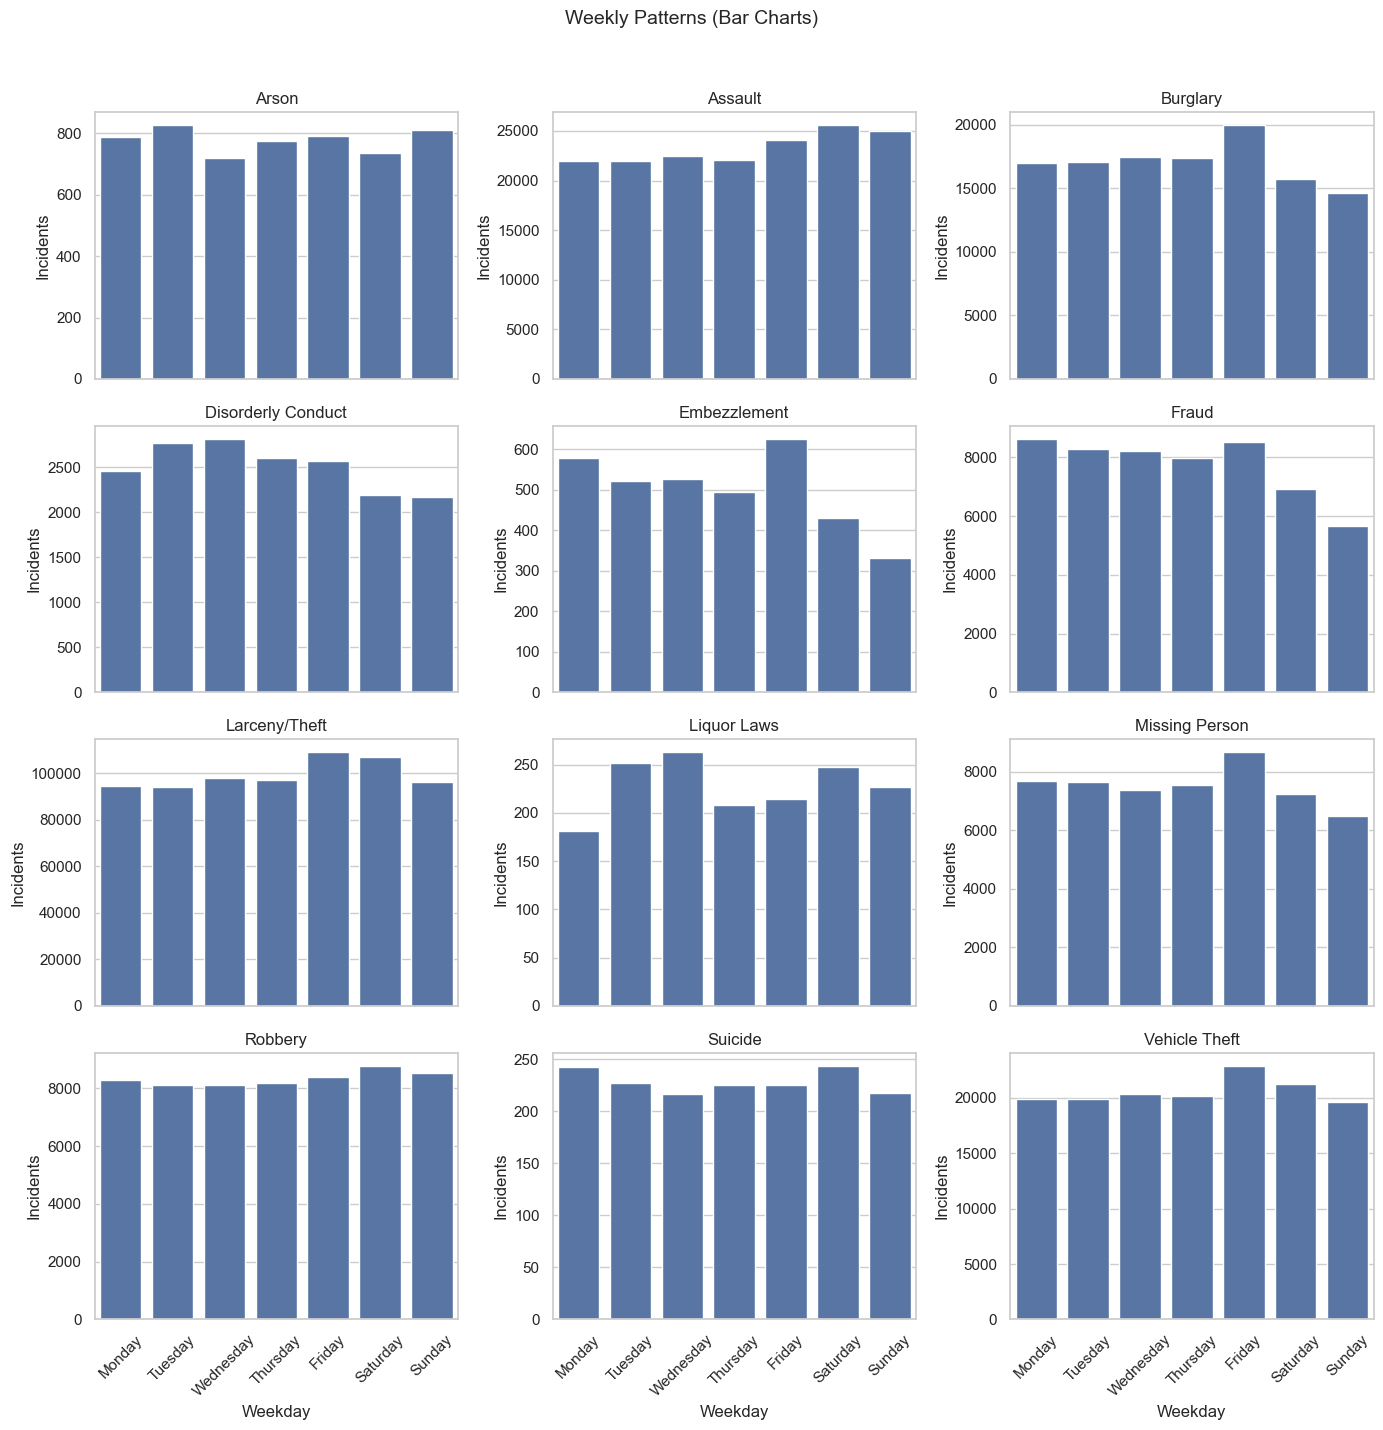

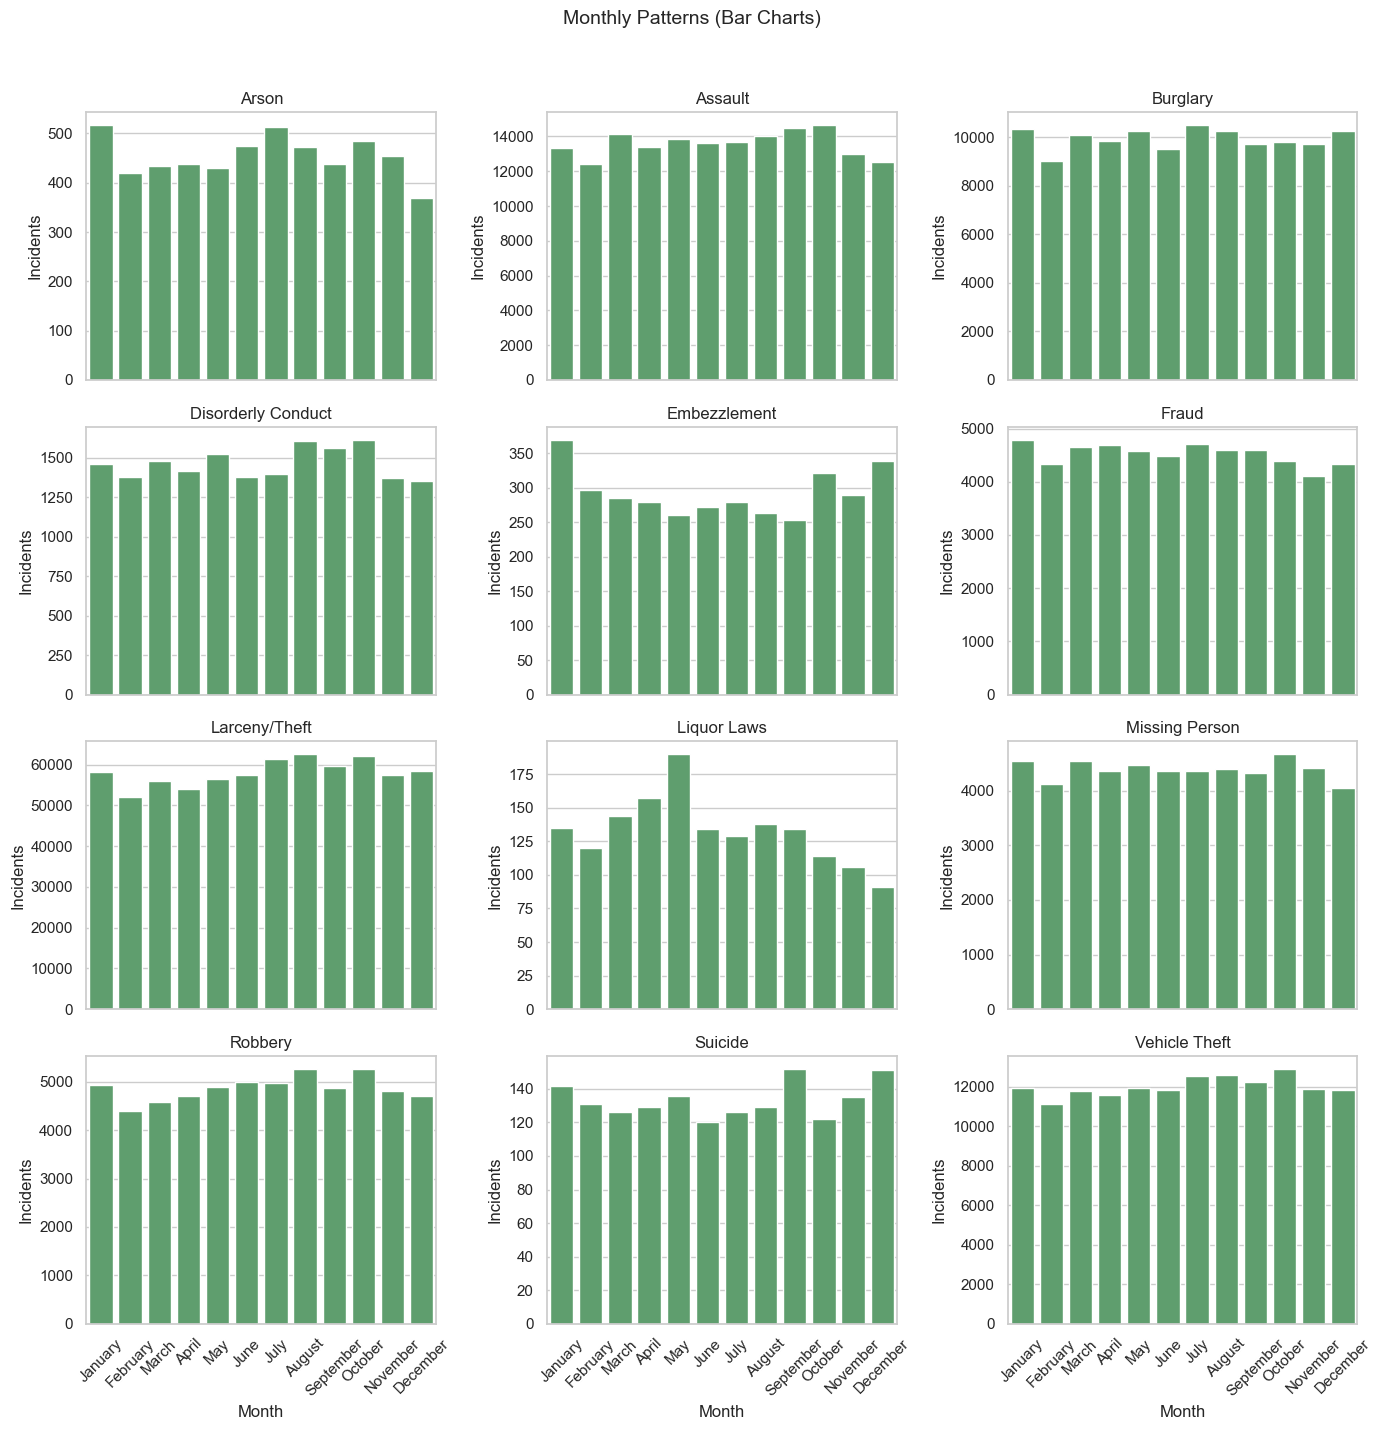

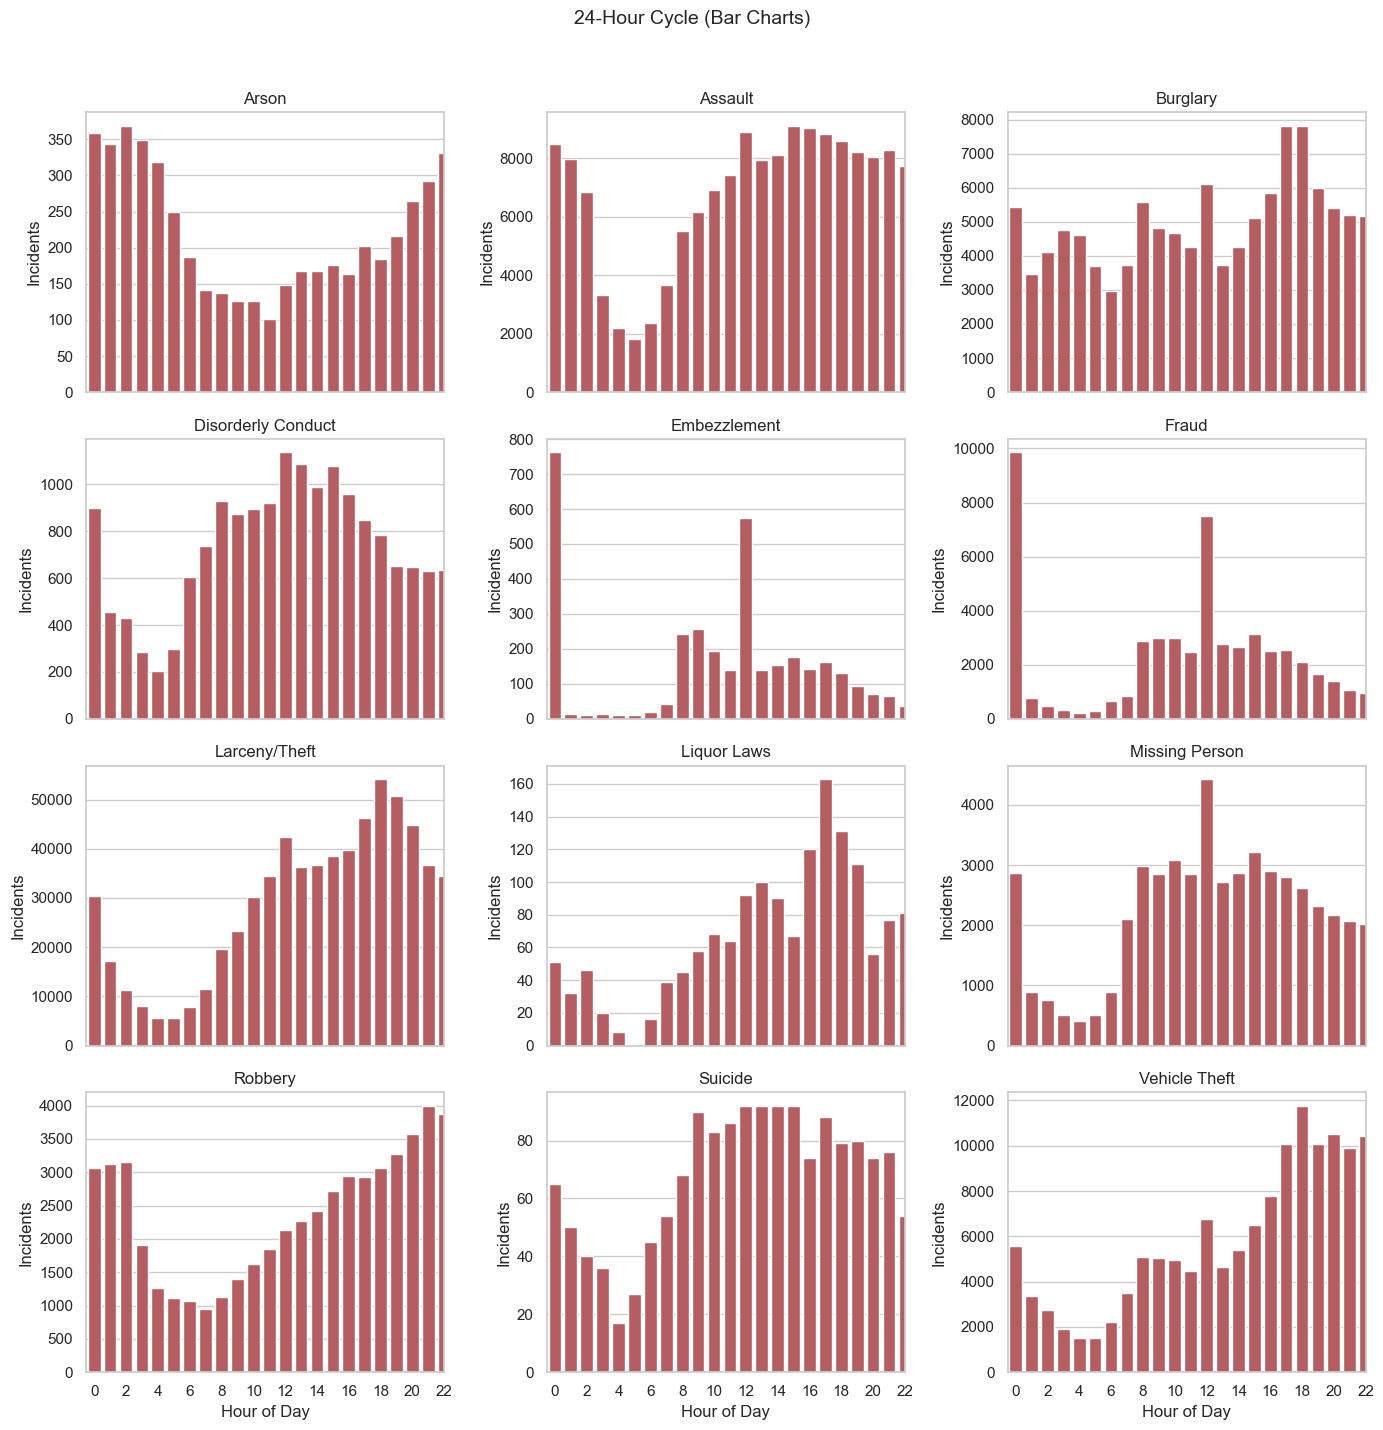

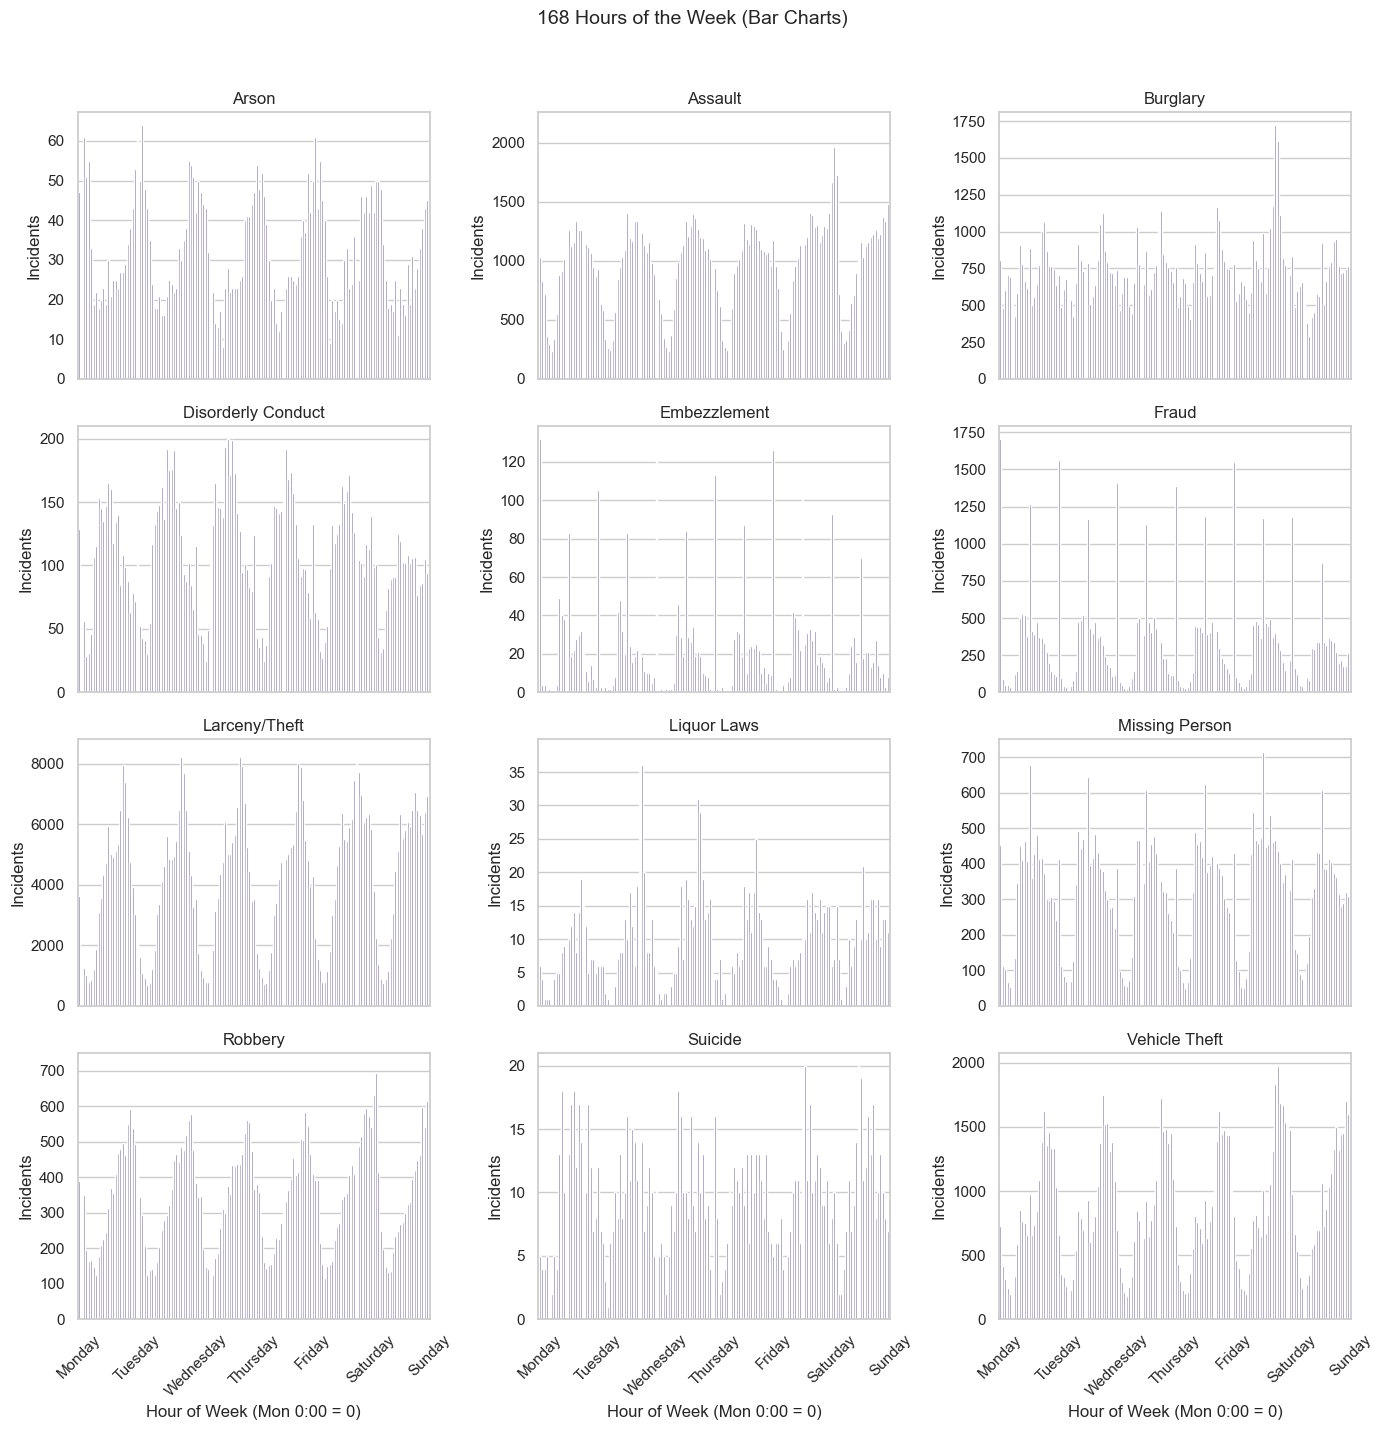

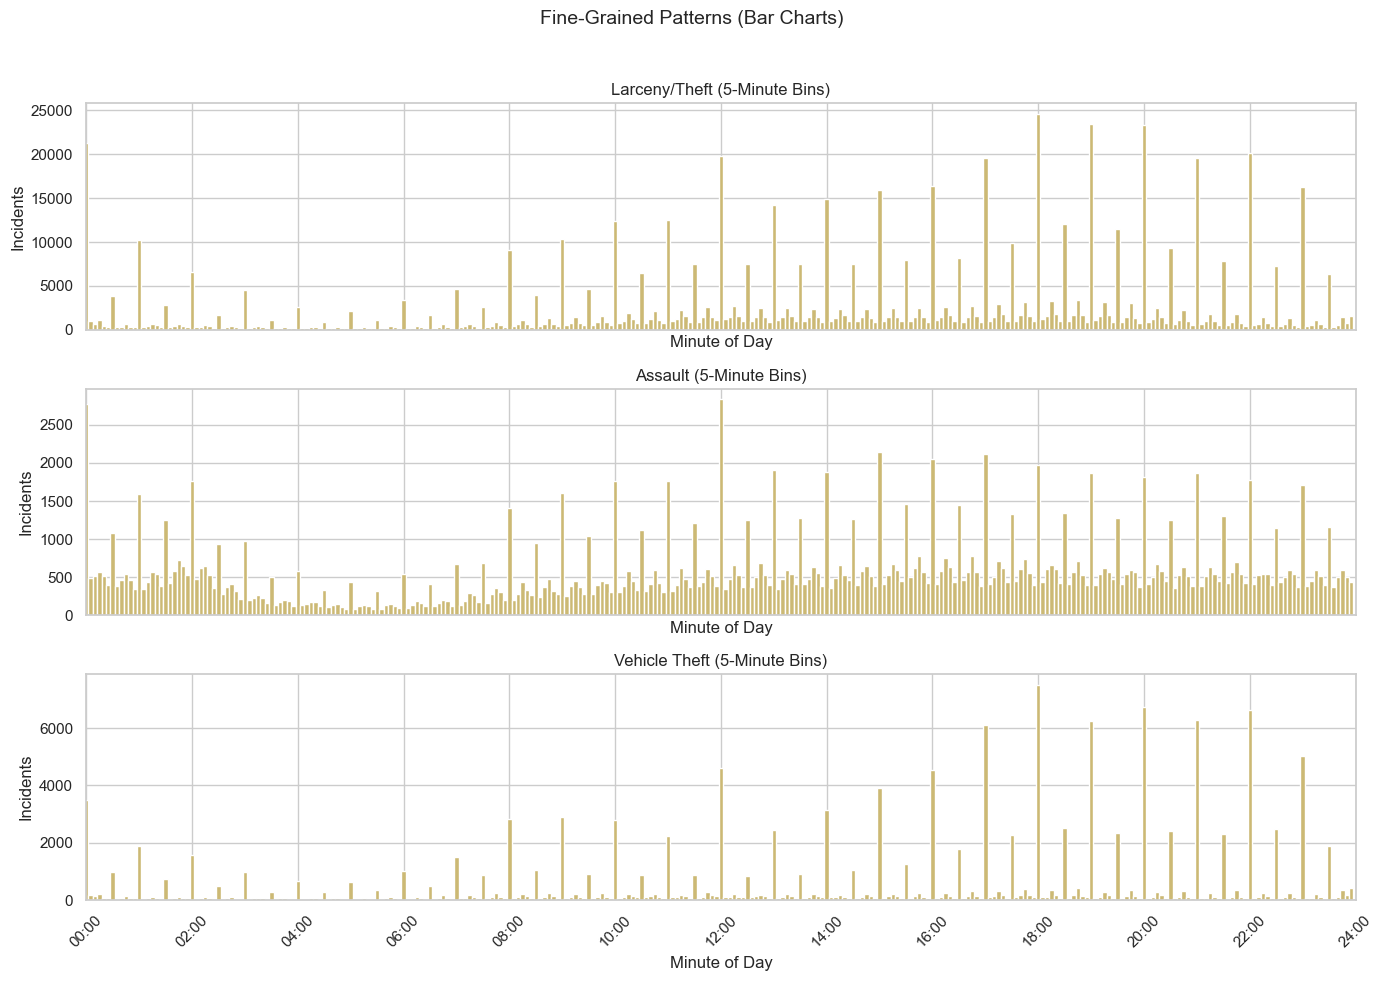

In [ ]:
# Exercise 3.1: Bar chart versions of the temporal patterns
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

data_path = "../files/merged_crime_data_2003_2025.csv"
df = pd.read_csv(data_path, parse_dates=["Incident_Date"])

# Keep only records with unified categories
df = df[df["Unified_Category"].notna()].copy()

# Derived time fields
df["MonthName"] = df["Incident_Date"].dt.month_name()
df["DayName"] = df["Incident_Date"].dt.day_name()
df["DayOfWeek"] = df["Incident_Date"].dt.dayofweek

time_parsed = pd.to_datetime(df["Incident_Time"], format="%H:%M", errors="coerce")
df["Hour"] = time_parsed.dt.hour
df["Minute"] = time_parsed.dt.minute

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
],
if isinstance(month_order, tuple):
    month_order = month_order[0]

categories = sorted(df["Unified_Category"].unique())
n_cols = 3
n_rows = (len(categories) + n_cols - 1) // n_cols

# ---- Weekly patterns (bar charts) ----
weekly_counts = (
    df.groupby(["DayName", "Unified_Category"])
    .size()
    .reset_index(name="Count")
)
weekly_counts["DayName"] = pd.Categorical(weekly_counts["DayName"], categories=weekday_order, ordered=True)
weekly_counts = weekly_counts.sort_values("DayName")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows), sharex=True)
axes = axes.flatten()
for ax, category in zip(axes, categories):
    subset = weekly_counts[weekly_counts["Unified_Category"] == category]
    subset = subset.set_index("DayName").reindex(weekday_order, fill_value=0).reset_index()
    sns.barplot(data=subset, x="DayName", y="Count", ax=ax, color="#4C72B0")
    ax.set_title(category)
    ax.set_xlabel("Weekday")
    ax.set_ylabel("Incidents")
    ax.tick_params(axis="x", rotation=45)
for ax in axes[len(categories):]:
    ax.set_visible(False)
fig.suptitle("Weekly Patterns (Bar Charts)", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

# ---- Monthly patterns (bar charts) ----
monthly_counts = (
    df.groupby(["MonthName", "Unified_Category"])
    .size()
    .reset_index(name="Count")
)
monthly_counts["MonthName"] = pd.Categorical(monthly_counts["MonthName"], categories=month_order, ordered=True)
monthly_counts = monthly_counts.sort_values("MonthName")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows), sharex=True)
axes = axes.flatten()
for ax, category in zip(axes, categories):
    subset = monthly_counts[monthly_counts["Unified_Category"] == category]
    subset = subset.set_index("MonthName").reindex(month_order, fill_value=0).reset_index()
    sns.barplot(data=subset, x="MonthName", y="Count", ax=ax, color="#55A868")
    ax.set_title(category)
    ax.set_xlabel("Month")
    ax.set_ylabel("Incidents")
    ax.tick_params(axis="x", rotation=45)
for ax in axes[len(categories):]:
    ax.set_visible(False)
fig.suptitle("Monthly Patterns (Bar Charts)", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

# ---- 24-hour cycle (bar charts) ----
hourly_counts = (
    df.groupby(["Hour", "Unified_Category"])
    .size()
    .reset_index(name="Count")
)
hourly_counts = hourly_counts.dropna(subset=["Hour"])

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows), sharex=True)
axes = axes.flatten()
hour_bins = list(range(24))
for ax, category in zip(axes, categories):
    subset = hourly_counts[hourly_counts["Unified_Category"] == category]
    subset = subset.set_index("Hour").reindex(hour_bins, fill_value=0).reset_index()
    sns.barplot(data=subset, x="Hour", y="Count", ax=ax, color="#C44E52")
    ax.set_title(category)
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Incidents")
    ax.set_xticks(range(0, 24, 2))
for ax in axes[len(categories):]:
    ax.set_visible(False)
fig.suptitle("24-Hour Cycle (Bar Charts)", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

# ---- 168 hours of the week (bar charts) ----
df["HourOfWeek"] = df["DayOfWeek"] * 24 + df["Hour"]
hour_of_week_counts = (
    df.groupby(["HourOfWeek", "Unified_Category"])
    .size()
    .reset_index(name="Count")
)
hour_of_week_counts = hour_of_week_counts.dropna(subset=["HourOfWeek"])

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows), sharex=True)
axes = axes.flatten()
week_bins = list(range(168))
for ax, category in zip(axes, categories):
    subset = hour_of_week_counts[hour_of_week_counts["Unified_Category"] == category]
    subset = subset.set_index("HourOfWeek").reindex(week_bins, fill_value=0).reset_index()
    sns.barplot(data=subset, x="HourOfWeek", y="Count", ax=ax, color="#8172B2")
    ax.set_title(category)
    ax.set_xlabel("Hour of Week (Mon 0:00 = 0)")
    ax.set_ylabel("Incidents")
    ax.set_xticks(range(0, 168, 24))
    ax.set_xticklabels(weekday_order, rotation=45)
for ax in axes[len(categories):]:
    ax.set_visible(False)
fig.suptitle("168 Hours of the Week (Bar Charts)", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

# ---- 5-minute bins (bar charts for top 3 categories) ----
top_categories = (
    df["Unified_Category"].value_counts().head(3).index.tolist()
)
df_top = df[df["Unified_Category"].isin(top_categories)].copy()
df_top = df_top.dropna(subset=["Hour", "Minute"])

df_top["MinuteOfDay"] = df_top["Hour"] * 60 + df_top["Minute"]
df_top["Bin5"] = (df_top["MinuteOfDay"] // 5) * 5

bin_counts = (
    df_top.groupby(["Bin5", "Unified_Category"])
    .size()
    .reset_index(name="Count")
)

fig, axes = plt.subplots(len(top_categories), 1, figsize=(14, 3.2 * len(top_categories)), sharex=True)
if len(top_categories) == 1:
    axes = [axes]
bin5_bins = list(range(0, 24 * 60, 5))
for ax, category in zip(axes, top_categories):
    subset = bin_counts[bin_counts["Unified_Category"] == category]
    subset = subset.set_index("Bin5").reindex(bin5_bins, fill_value=0).reset_index()
    ax.bar(subset["Bin5"], subset["Count"], width=5, color="#CCB974")
    ax.set_title(f"{category} (5-Minute Bins)")
    ax.set_xlabel("Minute of Day")
    ax.set_ylabel("Incidents")
    ax.set_xlim(0, 24 * 60)
    ax.set_xticks(range(0, 24 * 60 + 1, 120))
    ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 25, 2)], rotation=45)
fig.suptitle("Fine-Grained Patterns (Bar Charts)", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

## Part 4: Exploring other types of plots for temporal data

We now take a mini-break from barcharts and exploring more ways to plot temporal data.

> **Exercise 4.1**: Other cool ways to plot temporal data
>
> I am going to introduce four different plot-types. Then your job is to choose a part of the crime-data that you care about and plot it using these new ways of visualizing data. I recommend that you choose a different part of the crime-data for each plot-type.
>
> * **Calendar plots**. Get started on calendar plots **[here](https://calplot.readthedocs.io/en/latest/)**. There are other packages for plotting these, those are also OK to use.
> * **Polar bar chart**. Here I want you to plot a 24-hour pattern of some sort — those work really well in radial plots (another name for polar plots) because the day wraps around on itself. You can also try plotting data with patterns from the 168 hours of the week. There's not one super-awesome solution here, you can try using [pure matplotlib](https://matplotlib.org/stable/gallery/pie_and_polar_charts/polar_bar.html) ... [some examples here](https://www.python-graph-gallery.com/circular-barplot/) or via [plotly](https://plotly.com/python/polar-chart/) (scroll down a bit for the polar barchart).
> * **Time series**. Time series is a key functionality of Pandas. To get started, check out the [pandas time series documentation](https://pandas.pydata.org/docs/user_guide/timeseries.html) and the guide on [plotting with a DatetimeIndex](https://pandas.pydata.org/docs/user_guide/visualization.html#plotting-with-a-datetimeindex). For resampling data to different time frequencies (daily, weekly, monthly), see [DataFrame.resample()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html).
> * **Heatmaps**. A heatmap showing hour-of-day vs day-of-week is a classic way to visualize temporal patterns. This pairs nicely with your 168-hour analysis from Exercise 3.1. Get started with [seaborn.heatmap()](https://seaborn.pydata.org/generated/seaborn.heatmap.html) — you'll need to pivot your data into a matrix first.
> * **Reflection**: What did you learn from using LLMs to solve these visualization challenges?

<div class="alert alert-block alert-info">
<b>LLM guidance:</b> For this exercise, you may use the full power of your LLM! Go nuts and see if you can get these plots working by fully relying on LLM-generated code. This is a deliberate contrast to the previous exercises — afterward, reflect on what was different about this experience.
</div>

**Note**: I added this exercise with fewer hints than usual. Normally, I help you break down the problems into small solvable bits. Since this is an LLM-heavy exercise, I haven't done that. But I encourage you to play with figuring out the steps yourself — and compare your breakdown to what the LLM suggests.

This ties into a bigger picture thing about data science.

*My philosophy for data science is this*: Getting to what you want rarely seems hard once you found your way there, the difficulty comes in breaking down a hard problem into the little steps you need to take to solve your complex problem. In this class, I usually do the breaking down for you and provide you with the steps (that's how you go from nothing to creating complex visualizations of crime-data). But I also want you to learn the breaking-problems-down part. LLMs can help here - they can tell you how to break down problems into smaller bits - but if you don't try yourself, you'll never get good at it. So always create your own breakdown first; then see what the computer thinks.

*My approach is always to think something along these lines*: Even if my task seems impossible, I think: "is there any problem that I ***CAN*** solve that will get me closer to where I want to go?" Once I've solved that part, I'm smarter and I try to think: "Is there a new problem I can solve that'll get me closer knowing what I know now?" And I just keep going. Usually that's enough.

findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

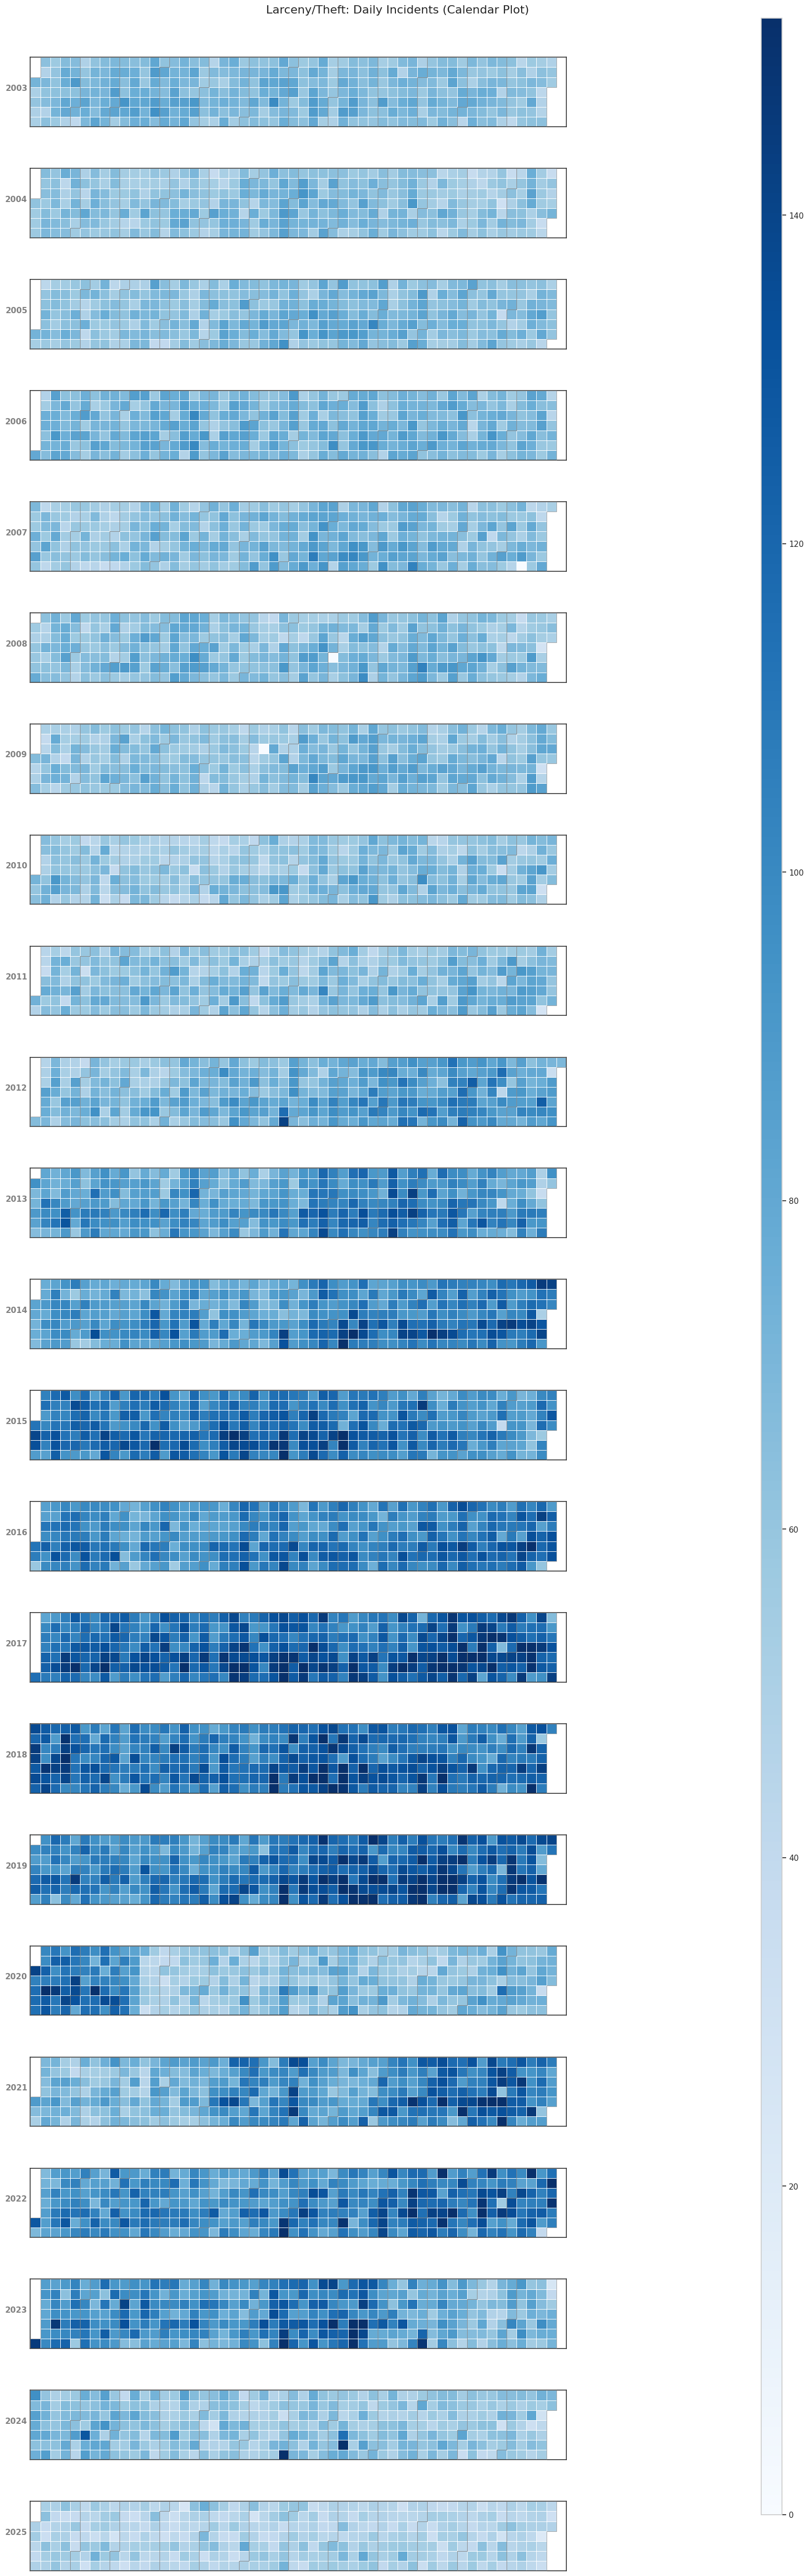

In [ ]:
import calendar
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import calplot

plt.rcParams["font.family"] = "DejaVu Sans"

data_path = "../files/merged_new_csv.csv"
df = pd.read_csv(data_path, parse_dates=["Incident_Date"])
df = df[df["Unified_Category"].notna()].copy()

# Most frequent category
category = df["Unified_Category"].value_counts().idxmax()

# Daily counts
daily_counts = (
    df[df["Unified_Category"] == category]
    .set_index("Incident_Date")
    .resample("D")
    .size()
)

# Ensure continuous full date range (important for calendar plots)
full_range = pd.date_range(daily_counts.index.min(), daily_counts.index.max(), freq="D")
daily_counts = daily_counts.reindex(full_range, fill_value=0)
daily_counts.index.name = "Date"

day_labels = list(calendar.day_abbr)
month_labels = list(calendar.month_abbr)[1:]

# Lock color scale so intensity is comparable across years
vmax = daily_counts.quantile(0.99)

# ~2.2 units of height per year keeps each row readable
n_years = daily_counts.index.year.nunique()
fig_height = max(12, n_years * 2.2)

fig, axes = calplot.calplot(
    daily_counts,
    cmap="Blues",
    vmin=0,
    vmax=vmax,
    figsize=(20, fig_height),
    suptitle=f"{category}: Daily Incidents (Calendar Plot)",
    yearlabels=True,
    daylabels=day_labels,
    dayticks=False,
    monthlabels=month_labels,
    monthticks=False,
    linewidth=0.5,
    edgecolor="gray",
    yearascending=True,
)

# Add a visible frame around each year and fix year labels
for ax in axes:
    # Draw a rectangle border around the axes
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
        spine.set_edgecolor("#333333")

    # Year labels horizontal and readable
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha("right")
    ax.yaxis.label.set_fontsize(11)

# Better spacing for title
fig.subplots_adjust(top=0.96, hspace=0.6)
fig.suptitle(f"{category}: Daily Incidents (Calendar Plot)", fontsize=16, y=0.98)

plt.show()

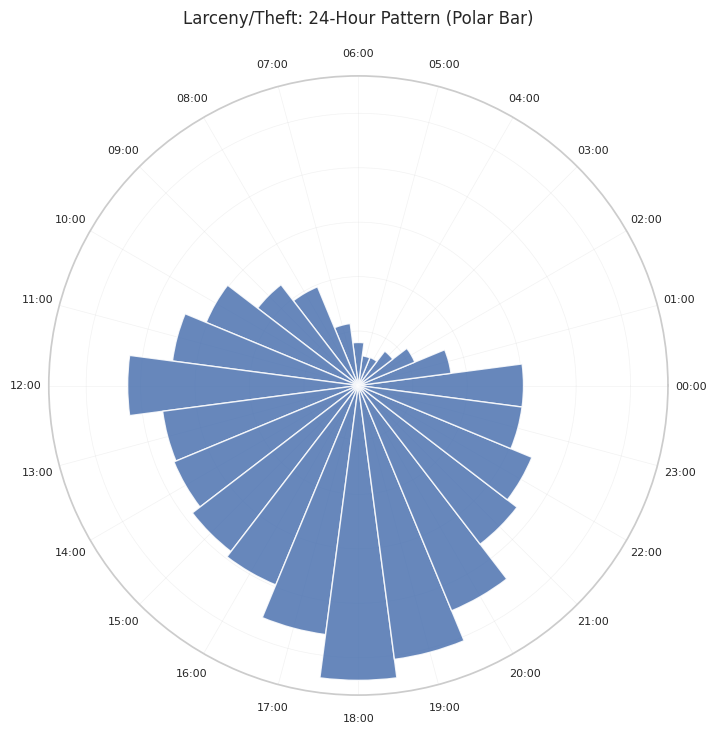

In [ ]:
# Exercise 4.1: Polar bar chart (24-hour pattern for one category)
import numpy as np
import matplotlib.pyplot as plt

time_parsed = pd.to_datetime(df["Incident_Time"], format="%H:%M", errors="coerce")
df["Hour"] = time_parsed.dt.hour

hour_counts = (
    df[df["Unified_Category"] == category]
    .groupby("Hour")
    .size()
    .reindex(range(24), fill_value=0)
 )

angles = np.linspace(0, 2 * np.pi, 24, endpoint=False)
width = 2 * np.pi / 24
fig, ax = plt.subplots(figsize=(7.5, 7.5), subplot_kw={"polar": True})
ax.bar(angles, hour_counts.values, width=width, bottom=0.0, color="#4C72B0", alpha=0.85)
ax.set_title(f"{category}: 24-Hour Pattern (Polar Bar)", pad=18)
ax.set_xticks(angles)
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], fontsize=8)
ax.set_yticklabels([])
ax.grid(True, linewidth=0.5, alpha=0.25)
ax.set_facecolor("white")
plt.tight_layout()
plt.show()

C:\Users\abina\AppData\Local\Temp\ipykernel_21264\1552606767.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
C:\Users\abina\AppData\Local\Temp\ipykernel_21264\1552606767.py:11: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .size()


NameError: name 'apply_clean_style' is not defined

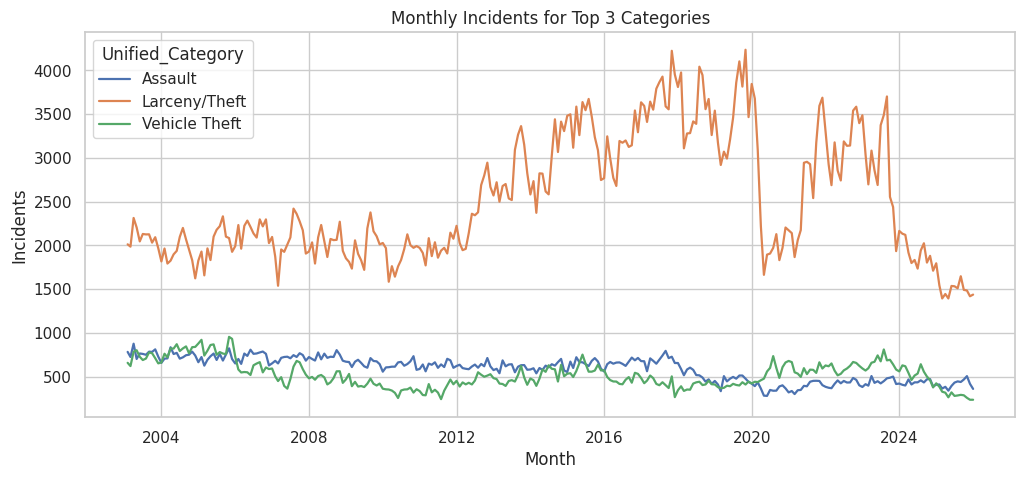

In [ ]:
# Exercise 4.1: Time series (monthly totals for top categories)
import seaborn as sns

top_categories = df["Unified_Category"].value_counts().head(3).index.tolist()
df_ts = df[df["Unified_Category"].isin(top_categories)].copy()

monthly = (
    df_ts.set_index("Incident_Date")
    .groupby("Unified_Category")
    .resample("M")
    .size()
    .rename("Count")
    .reset_index()
 )

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=monthly, x="Incident_Date", y="Count", hue="Unified_Category", ax=ax, linewidth=1.6)
ax.set_title("Monthly Incidents for Top 3 Categories")
ax.set_xlabel("Month")
ax.set_ylabel("Incidents")
apply_clean_style(ax)
ax.margins(x=0.01)
plt.tight_layout()
plt.show()

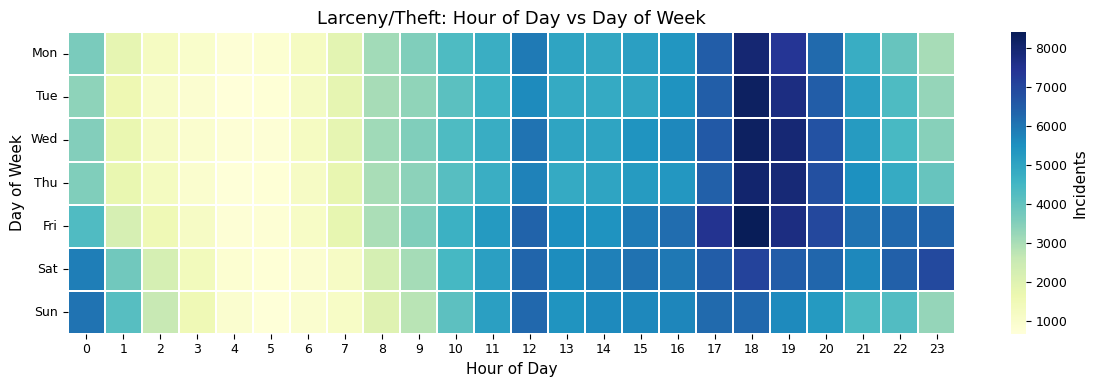

In [ ]:
# Exercise 4.1: Heatmap (day of week vs hour of day)
heat_category = category
df_heat = df[df["Unified_Category"] == heat_category].copy()

df_heat["DayOfWeek"] = df_heat["Incident_Date"].dt.dayofweek
df_heat["Hour"] = pd.to_datetime(df_heat["Incident_Time"], format="%H:%M", errors="coerce").dt.hour
df_heat = df_heat.dropna(subset=["Hour"])

heat = (
    df_heat.groupby(["DayOfWeek", "Hour"])
    .size()
    .reset_index(name="Count")
    .pivot(index="DayOfWeek", columns="Hour", values="Count")
    .fillna(0)
 )

day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    heat,
    ax=ax,
    cmap="YlGnBu",
    cbar_kws={"label": "Incidents"},
    linewidths=0.2,
    linecolor="white",
)
ax.set_title(f"{heat_category}: Hour of Day vs Day of Week")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Day of Week")
ax.set_yticklabels(day_labels, rotation=0)
apply_clean_style(ax)
plt.tight_layout()
plt.show()

## Exercise 4.1 Reflection
- What was easiest to get working, and why?
- Where did the LLM help most (debugging, structure, syntax)?
- What did you still need to decide yourself (data choices, design, interpretation)?
- One thing you would change if you rebuilt the plots from scratch.

---

## You've Completed Week 2!

This week you tackled one of the messiest but most important skills in data science: merging imperfect datasets. You now have:

- A unified crime dataset spanning 2003 to the present
- Experience with schema mapping and category matching
- A documented set of Personal Focus Crimes that you can track confidently over time
- New visualization techniques (calendar plots, polar charts, time series)

**Key takeaways:**
- Real-world data is messy. Categories change, formats differ, and documentation is often missing.
- The assumptions you make during data cleaning directly affect what conclusions you can draw.
- Validation is crucial — always check that your merged data makes sense at the boundaries.
- Understanding *why* data looks the way it does is just as important as knowing *how* to process it.

If you want to go further:
- Explore spatial patterns in your merged dataset — which neighborhoods show the most change over 20 years? Do any neighborhoods have different patterns than the city as a whole?
- Try different category mappings and see how they affect your conclusions
- Look for "structural breaks" — points where the data changes in ways that might reflect policy changes, not actual crime changes
- Compare your Personal Focus Crimes list with a classmate's — did you make different choices? Why?